# 0f — Build Object B in SATURN macrogene space (ep75 + ep100)

* **Developed by:** Anna Maguza
* **Affilation:** CellZome, a GSK company
* **Created date:** 2026-05-08
* **Last modified date:** 2026-05-17

Per SPEC §5.1, build two macrogene-space objects from SATURN checkpoints — the user chose to evaluate **both** ep75 (lowest cross-species MMD) and ep100 (final, highest logreg accuracy) and let scIB pick the winner.

Each output object:
- `X` = 256-d macrogene expression (from SATURN output `.X`).
- `obsm['X_saturn']` = SATURN latent (also 256-d, from `obsm['macrogenes']`).
- `obs` = full atlas/LGR5 metadata, taken positionally from `saturn_input_human.h5ad` + `saturn_input_mouse.h5ad` (row-aligned with SATURN output).
- Per SPEC §2: `lgr5_status` ∈ {LGR5+, LGR5−, LGR5_unknown}; `lgr5_label` built per rules in 0g.
- Mouse metadata gaps backfilled the same way as `0e_audit_object_B_orth` (tissue → organism_part / gut_region; Study_name → age_group / ArrayExpress_ID).

Diagnostic figures: UMAP grid (ep75 vs ep100 × species/Study_name/cell_states/lgr5_status) + SATURN epoch-loss curves with ep75 and ep100 marked.


In [1]:
import sys, datetime as dt, gc
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

REPO     = Path('/Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis')
DATA_OUT = Path('/Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced')
SAT_DIR  = DATA_OUT / 'saturn_run' / 'saturn_results'
FIG_DIR  = REPO / 'analysis_enhanced' / 'figures' / '0_inputs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO / 'analysis_enhanced'))
from _lgr5_common import (
    apply_style, WES_PALETTE, LGR5_STATUS_PALETTE, CELL_STATE_PALETTE,
    embedding_scatter, umap_axes,
)
apply_style()

/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


## 2. Load SATURN inputs (full obs) and the two epoch checkpoints

In [2]:
h_in = sc.read_h5ad(DATA_OUT / 'saturn_input_human.h5ad')
m_in = sc.read_h5ad(DATA_OUT / 'saturn_input_mouse.h5ad')
print('saturn_input_human:', h_in.shape)
print('saturn_input_mouse:', m_in.shape)

ep75_h5  = SAT_DIR / 'test256_data_saturn_input_human_saturn_input_mouse_org_saturn_seed_0_ep_75.h5ad'
ep100_h5 = SAT_DIR / 'test256_data_saturn_input_human_saturn_input_mouse_org_saturn_seed_0_ep_100.h5ad'
sat_ep75  = sc.read_h5ad(ep75_h5)
sat_ep100 = sc.read_h5ad(ep100_h5)
print('SATURN ep75:', sat_ep75.shape, 'obsm:', list(sat_ep75.obsm.keys()))
print('SATURN ep100:', sat_ep100.shape, 'obsm:', list(sat_ep100.obsm.keys()))

assert sat_ep75.n_obs == h_in.n_obs + m_in.n_obs, 'row count mismatch'
assert sat_ep75.n_vars == 256, f'macrogene count = {sat_ep75.n_vars}, expected 256'

saturn_input_human: (102460, 57130)
saturn_input_mouse: (25485, 117786)


SATURN ep75: (127945, 256) obsm: ['macrogenes']
SATURN ep100: (127945, 256) obsm: ['macrogenes']


/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 3. Build the shared obs (human + mouse concat) and metadata fixups

Same logic as `0e_audit_object_B_orth`:
1. Concat `saturn_input_human.obs` and `saturn_input_mouse.obs` (row order matches SATURN output).
2. Rename `lgr5_status` value `'unknown'` → `'LGR5_unknown'` (per SPEC §2).
3. Backfill mouse `organism_part`, `gut_region`, `age_group`, `celltype`, `ArrayExpress_ID`.
4. Build `lgr5_label` (atlas/Ishikawa unsorted → cell_states; FACS LGR5+/− → 'LGR5+'/'LGR5−'; unsorted mouse without cell_states → 'Unknown').


In [3]:
def build_shared_obs(h_in, m_in):
    h = h_in.obs.copy()
    m = m_in.obs.copy()
    # Make index globally unique (human_<i>__<orig>, mouse_<i>__<orig>)
    h.index = [f'human_{i:06d}__{str(x)}' for i, x in enumerate(h.index)]
    m.index = [f'mouse_{i:06d}__{str(x)}' for i, x in enumerate(m.index)]
    obs = pd.concat([h, m], axis=0, ignore_index=False)
    return obs

shared_obs = build_shared_obs(h_in, m_in)
print('shared obs:', shared_obs.shape)
print('species counts:', shared_obs['species'].value_counts().to_dict())

tissue_to_organism = {'small intestine':'small intestine', 'intestinal organoid':'organoid', 'pyloric stomach':'pyloric stomach'}
tissue_to_gut_region = {'small intestine':'small intestine', 'intestinal organoid':'small intestine', 'pyloric stomach':'stomach'}
study_to_age = {
    'Yan 2017 GSE92865 (10x)':'adult', 'Yan/Kuo 2017 GSE99457 (10x)':'adult',
    'GSE145866 (10x)':'adult', 'Haber 2017 (Smart-Seq2)':'adult',
    'Grün 2015 GSE62270 (CEL-Seq)':'adult', 'Grün 2016 (CEL-Seq)':'adult',
    'Simmini 2014 GSE62784':'cell culture model',
}
study_to_aeid = {
    'Elementaite_2021':'E-MTAB-8901+9489+9543+9720+9536',
    'Holloway_2021':'GSE181039', 'Ishikawa 2022 (10x)':'Ishikawa2022',
    'Yan 2017 GSE92865 (10x)':'GSE92865', 'Yan/Kuo 2017 GSE99457 (10x)':'GSE99457',
    'GSE145866 (10x)':'GSE145866', 'Haber 2017 (Smart-Seq2)':'GSE92332',
    'Grün 2015 GSE62270 (CEL-Seq)':'GSE62270', 'Grün 2016 (CEL-Seq)':'GSE62270',
    'Simmini 2014 GSE62784':'GSE62784',
}

is_mouse = (shared_obs['species'].astype(str) == 'mouse').values

def fill_col(col, mapping, source_col='tissue', default='unknown'):
    if col not in shared_obs.columns:
        shared_obs[col] = default
    s = shared_obs[col].astype(object).copy()
    src = shared_obs[source_col].astype(object).to_numpy() if source_col in shared_obs.columns else np.array(['unknown']*len(s))
    for i in np.where(is_mouse)[0]:
        s.iloc[i] = mapping.get(src[i], default)
    shared_obs[col] = pd.Categorical(s)

fill_col('organism_part', tissue_to_organism, 'tissue')
fill_col('gut_region',    tissue_to_gut_region, 'tissue')
fill_col('age_group',     study_to_age, 'Study_name', default='adult')

# celltype = 'Epithelial' for all mouse
if 'celltype' not in shared_obs.columns:
    shared_obs['celltype'] = 'Epithelial'
ct = shared_obs['celltype'].astype(object).copy()
for i in np.where(is_mouse)[0]:
    ct.iloc[i] = 'Epithelial'
shared_obs['celltype'] = pd.Categorical(ct)

# ArrayExpress_ID per study
sn = shared_obs['Study_name'].astype(object).to_numpy()
shared_obs['ArrayExpress_ID'] = pd.Categorical([study_to_aeid.get(s, 'unknown') for s in sn])

# lgr5_status — strict vocab
if 'lgr5_status' in shared_obs.columns:
    s = shared_obs['lgr5_status'].astype(str).replace({'unknown':'LGR5_unknown'})
    shared_obs['lgr5_status'] = pd.Categorical(s, categories=['LGR5+','LGR5-','LGR5_unknown'])
else:
    shared_obs['lgr5_status'] = pd.Categorical(['LGR5_unknown'] * len(shared_obs))

# lgr5_label per rules in 0g
cs = shared_obs['cell_states'].astype(str)
st = shared_obs['lgr5_status'].astype(str)
label = cs.copy()
label[st == 'LGR5+'] = 'LGR5+'
label[st == 'LGR5-'] = 'LGR5-'
unknown_mask = (cs.isin(['unknown','nan','NaN','None'])) & (st == 'LGR5_unknown')
label[unknown_mask] = 'Unknown'
shared_obs['lgr5_label'] = pd.Categorical(label)

print('\nlgr5_status:', shared_obs['lgr5_status'].value_counts().to_dict())
print('lgr5_label:',  shared_obs['lgr5_label'].value_counts().to_dict())
print('age_group:',    shared_obs['age_group'].value_counts().to_dict())

shared obs: (127945, 105)
species counts: {'human': 102460, 'mouse': 25485}



lgr5_status: {'LGR5+': 18739, 'LGR5_unknown': 9045, 'LGR5-': 4804}
lgr5_label: {'Enterocyte': 28751, 'Proximal progenitor': 26304, 'LGR5+': 18739, 'TA': 17769, 'Stem cells': 14209, 'Colonocyte': 13449, 'LGR5-': 4804, 'Goblet': 1631, 'Prox1+ progenitor': 1336, 'BEST4+ epithelial': 469, 'Distal progenitor': 249, 'Secretory progenitor': 235}
age_group: {'adult': 40421, 'first trimester': 39314, 'second trimester': 24313, 'cell culture model': 16171, 'child stage': 623}


## 4. Assemble `object_b_macro_ep75` and `object_b_macro_ep100`


In [4]:
macrogene_names = [f'macrogene_{i:03d}' for i in range(256)]

def make_macro_obj(sat_adata, shared_obs, name):
    X = sat_adata.X
    Xd = X.toarray() if sp.issparse(X) else np.asarray(X)
    saturn_latent = np.asarray(sat_adata.obsm['macrogenes'])
    obj = ad.AnnData(
        X=Xd, obs=shared_obs.copy(),
        var=pd.DataFrame(index=macrogene_names),
        obsm={'X_saturn': saturn_latent},
    )
    obj.uns['processing_history'] = {
        f'object_b_macro_built_{dt.datetime.now().strftime("%Y%m%d_%H%M%S")}':
            f'Built from SATURN {name} checkpoint. obs from saturn_input_{{human,mouse}}.h5ad; '
            f'lgr5_status standardised; mouse metadata backfilled per SPEC §5.1.',
    }
    return obj

obj_ep75  = make_macro_obj(sat_ep75,  shared_obs, 'ep75')
obj_ep100 = make_macro_obj(sat_ep100, shared_obs, 'ep100')
print('object_b_macro_ep75:',  obj_ep75.shape)
print('object_b_macro_ep100:', obj_ep100.shape)

obj_ep75.write_h5ad(DATA_OUT  / 'object_b_macro_ep75.h5ad')
obj_ep100.write_h5ad(DATA_OUT / 'object_b_macro_ep100.h5ad')
print('wrote object_b_macro_ep75.h5ad and object_b_macro_ep100.h5ad')
del sat_ep75, sat_ep100; gc.collect()

object_b_macro_ep75: (127945, 256)
object_b_macro_ep100: (127945, 256)


wrote object_b_macro_ep75.h5ad and object_b_macro_ep100.h5ad


0

## 5. UMAP from `X_saturn` (both checkpoints)


In [5]:
for obj, name in [(obj_ep75, 'ep75'), (obj_ep100, 'ep100')]:
    sc.pp.neighbors(obj, use_rep='X_saturn', n_neighbors=30)
    sc.tl.umap(obj, random_state=0, min_dist=0.3)
    obj.write_h5ad(DATA_OUT / f'object_b_macro_{name}.h5ad')
    print(f'{name}: X_umap shape = {obj.obsm["X_umap"].shape}')

/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():


/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ep75: X_umap shape = (127945, 2)


/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():


ep100: X_umap shape = (127945, 2)


## 6. Diagnostic UMAP grid — ep75 vs ep100 × {species, Study, cell_states, lgr5_status}


/var/folders/8j/syfvxwvd4lggpmnnpd_r8jkr0000gp/T/ipykernel_53941/952094336.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


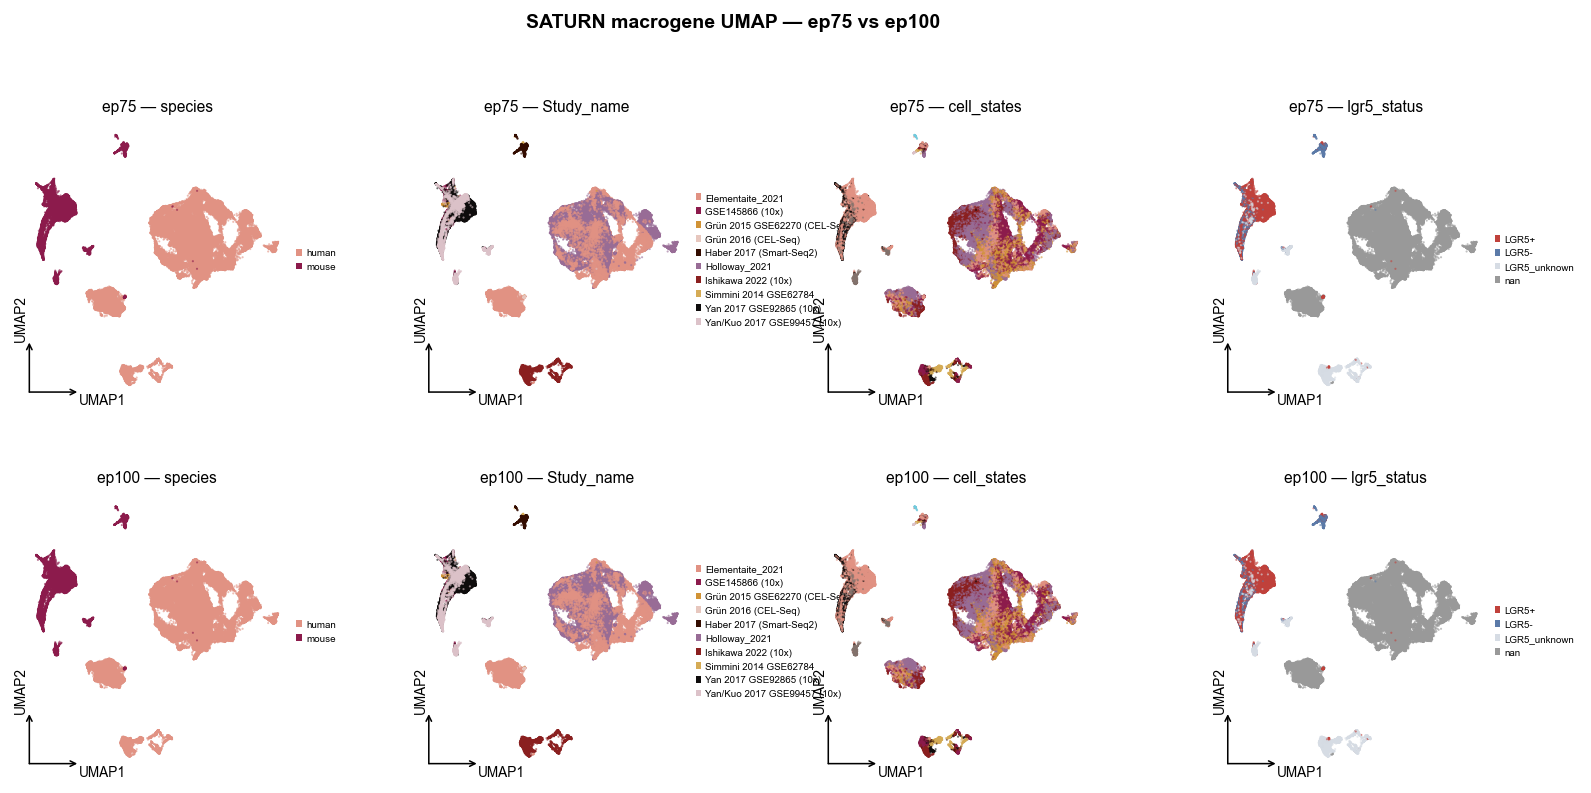

In [6]:
color_keys = ['species', 'Study_name', 'cell_states', 'lgr5_status']

def per_panel_palette(values, key):
    cats = pd.Categorical(values).categories
    if key == 'lgr5_status':
        return cats, [LGR5_STATUS_PALETTE.get(str(c), '#999999') for c in cats]
    if key == 'cell_states':
        return cats, [CELL_STATE_PALETTE.get(str(c), WES_PALETTE[i % len(WES_PALETTE)]) for i, c in enumerate(cats)]
    return cats, [WES_PALETTE[i % len(WES_PALETTE)] for i, _ in enumerate(cats)]

fig, axes = plt.subplots(2, len(color_keys),
                          figsize=(3.0 * len(color_keys) + 1.5, 6),
                          gridspec_kw={'wspace': 0.5, 'hspace': 0.35})
for row, (obj, name) in enumerate([(obj_ep75, 'ep75'), (obj_ep100, 'ep100')]):
    coords = obj.obsm['X_umap']
    for col, key in enumerate(color_keys):
        ax = axes[row, col]
        vals = obj.obs[key].astype(str).to_numpy()
        cats, palette = per_panel_palette(vals, key)
        embedding_scatter(ax, coords, values=vals, palette=palette,
                          s=1.2, alpha=0.6, sort_by_value=False)
        umap_axes(ax)
        ax.set_title(f'{name} — {key}', fontsize=8)
        handles = [Patch(facecolor=c, label=l) for l, c in zip(cats, palette)]
        if len(handles) <= 12:
            ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
                      frameon=False, fontsize=5, handlelength=0.6)

fig.suptitle('SATURN macrogene UMAP — ep75 vs ep100', fontsize=10, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'saturn_macrogene_umap__ep75_vs_ep100.pdf')
fig.savefig(FIG_DIR / 'saturn_macrogene_umap__ep75_vs_ep100.png', dpi=300)
plt.show()

## 7. SATURN epoch loss curves (ep75 and ep100 marked)


   epoch     score      type     human     mouse
0     25  0.961505    logreg  0.971924  0.951086
1     25  2.409044       MMD  2.465710  2.352379
2     25  0.005611  cross_lr       NaN       NaN
3     50  0.979254    logreg  0.993428  0.965080
4     50  1.808254       MMD  2.112954  1.503554


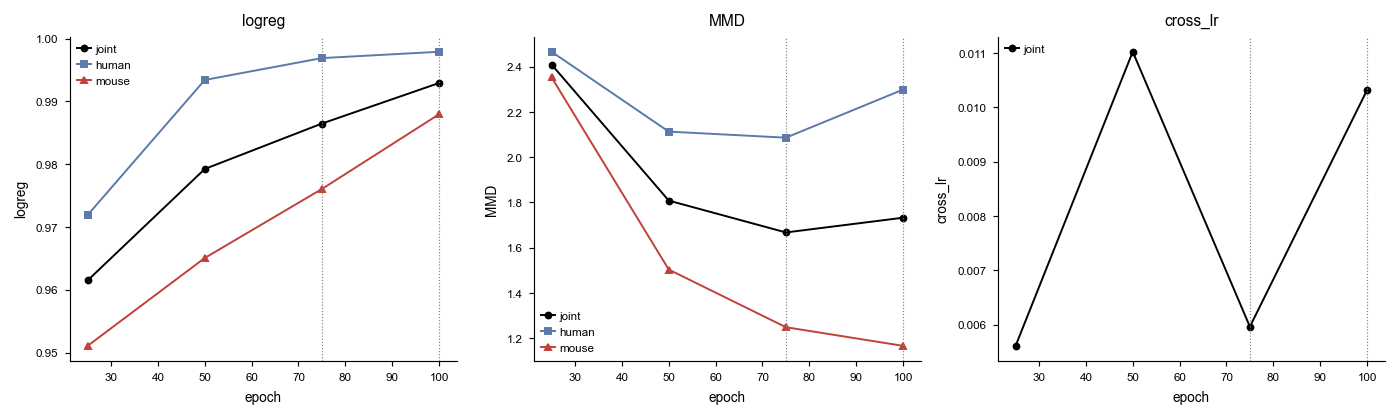

In [7]:
scores = pd.read_csv(SAT_DIR / 'test256_data_saturn_input_human_saturn_input_mouse_org_saturn_seed_0_epoch_scores.csv')
print(scores.head())

metrics = list(scores['type'].unique())
fig, axes = plt.subplots(1, len(metrics), figsize=(3.0 * len(metrics) + 1, 3.0), sharex=True)
if len(metrics) == 1:
    axes = [axes]
for ax, m in zip(axes, metrics):
    sub = scores[scores['type'] == m]
    ax.plot(sub['epoch'], sub['score'], marker='o', color='black', lw=1, label='joint')
    if 'human' in sub.columns and sub['human'].notna().any():
        ax.plot(sub['epoch'], sub['human'], marker='s', color='#5B7AA8', lw=1, label='human')
    if 'mouse' in sub.columns and sub['mouse'].notna().any():
        ax.plot(sub['epoch'], sub['mouse'], marker='^', color='#C0413B', lw=1, label='mouse')
    for ep in (75, 100):
        ax.axvline(ep, color='gray', ls=':', lw=0.6)
    ax.set_xlabel('epoch'); ax.set_ylabel(m); ax.legend(fontsize=6, frameon=False)
    ax.set_title(m, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'saturn_loss_curves.pdf')
fig.savefig(FIG_DIR / 'saturn_loss_curves.png', dpi=300)
plt.show()

## 8. Outputs

**Data** (under `/Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/`):
- `object_b_macro_ep75.h5ad` — Object B in 256-d SATURN macrogene space, SATURN ep75.
- `object_b_macro_ep100.h5ad` — same, ep100.

Both carry `obsm['X_saturn']` (256-d SATURN latent, the candidate no-model embedding per SPEC §5.2) and `obsm['X_umap']` computed from `X_saturn`.

**Figures** (under `analysis_enhanced/figures/0_inputs/`):
- `saturn_macrogene_umap__ep75_vs_ep100.{pdf,png}` — diagnostic UMAP grid.
- `saturn_loss_curves.{pdf,png}` — SATURN training curves with ep75/ep100 marked.
